In [1]:
import torch.nn as nn
from black_scholes.sobolev.bs_sobolev_nd import BlackScholesSobolevMultiAsset
from utility.model import EarlyStopping, ModelConfig
from config.bs_sobolev_nd import *

In [2]:
seeds = [67]
for seed in seeds:
    print(f'Training model with seed {seed}...')
    model = BlackScholesSobolevMultiAsset(model_config, seed=seed)
    model.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
    model.set_loss_weights(loss_weights)
    # early_stopping = EarlyStopping(patience=1000, min_delta=1e-7)
    early_stopping = None
    model.train(batch_size=4096, epochs=20000, early_stopping=early_stopping, anneal_freq=1000, alpha=0.9)
    model.save(f'../../models/bs_sobolev_nd/{seed}.pth')

Training model with seed 67...
Iter      0 | Train: 1.0017e+00 | Val: 1.3657e+00 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter    500 | Train: 1.1129e-02 | Val: 2.0719e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1000 | Train: 8.2203e-03 | Val: 1.4843e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1500 | Train: 7.4129e-03 | Val: 1.2441e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   2000 | Train: 6.5895e-03 | Val: 1.1635e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   2500 | Train: 5.3213e-03 | Val: 8.7893e-03 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   3000 | Train: 5.0774e-03 | Val: 7.2293e-03 | Weights: J2=0.342  J3=0.128  pde=0.471  J4=0.059
Iter   3500 | Train: 4.2963e-03 | Val: 6.6093e-03 | Weights: J2=0.342  J3=0.128  pde=0.471  J4=0.059
Iter   4000 | Train: 3.8728e-03 | Val: 5.7770e-03 | Weights: J2=0.075  J3=0.395  pde=0.471  J4=0.059
Iter   4500 | Train: 3.6157e-03 | Val: 8.8752e-03 | Weights:

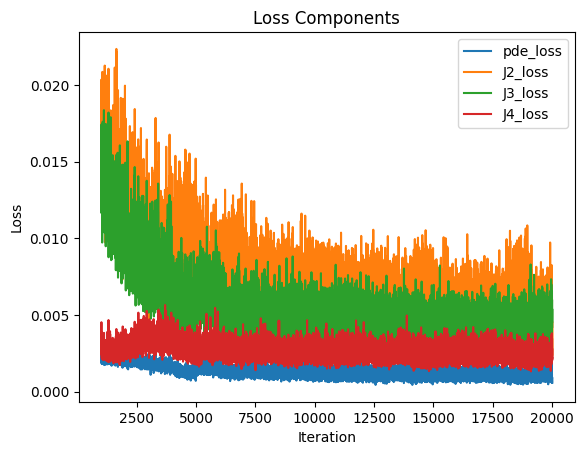

In [3]:
model.plot_losses(detailed=True, start_epoch=1000)